### For testing

In [264]:
#import libraries
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter

# import other functions
from app.pcr.sampleid_mapping import mapping_sampleid
from app.kits.selected_kit import load_selected_kit

In [265]:
file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_5516_5517.eds"
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
sample_ids = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_5516_5517_sample_id.xlsx"

sampleid_df = pd.read_excel(sample_ids, sheet_name="Sample_ID")
print(sampleid_df.head())

window=9
poly=2

   well  well_position    sample_id
0      1            A1  111749975.0
1      2            A2          NaN
2      3            A3  111208676.0
3      4            A4          NaN
4      5            A5  111869250.0


In [266]:

results = []
df = mapping_sampleid(file, sampleid_df)
df_final = df[df['cycle'] > 10]
channels = load_selected_kit(selected_kit_name)[2]

x = df_final['cycle'].values
abs_min_derivative_map = {
        "FAM": 6000, "VIC": 942, "ABY": 3000, "Cy5": 2583, "ROX": 8055 
    } 

for (well, well_position, sid), df_sample in df_final.groupby(['well', 'well_position', 'sample_id']):
    row_result = {"well": well, "well_position": well_position, 'sample_id': sid}
        
    
    channel_data = {}
    for ch in channels:
        if ch not in df_sample.columns: continue
        y = df_sample[ch].astype(float).values
        y_smooth = savgol_filter(y, window, poly)
        dy = savgol_filter(y_smooth, window, poly, deriv=1)
        x = df_final['cycle'].values
        dy_max = dy.max()
        abs_min = abs_min_derivative_map.get(ch, 3000)

        if dy_max < abs_min:
                row_result[ch] = "negatív"
                continue
    
        else: 
            d2y = savgol_filter(y_smooth, window, poly, deriv=2)
            mask = (dy > 0)
            
            if not np.any(mask):
                row_result[ch] = "negatív"
                continue

            valid_d2 = d2y[mask]
            #valid_x = x[mask]
            
            ct_idx_local = np.argmax(valid_d2)
            row_result[ch] = float(x[ct_idx_local])

    results.append(row_result)

results_df = pd.DataFrame(results)

results_df.to_excel("C:\\Users\\anett\\Downloads\\results_02.xlsx", index=False)



In [267]:
def evaluate_PCR_curves(
        file, 
        sampleid_df,
        selected_kit_name, 
        window=9,
        poly=2):
    
    results = []
    df = mapping_sampleid(file, sampleid_df)
    df_final = df[df['cycle'] > 10]
    channels = load_selected_kit(selected_kit_name)[2]
    x = df_final['cycle'].values

    # Alapmeredekség beállítása csatornánként
    abs_min_derivative_map = {
        "FAM": 6000, "VIC": 2500, "ABY": 3000, "Cy5": 3000, "ROX": 8000 } 

    # c
    for (well, well_position, sid), df_sample in df_final.groupby(['well', 'well_position', 'sample_id']):
        row_result = {"well": well, "well_position": well_position, 'sample_id': sid}
        
        for ch in channels:
            if ch not in df_sample.columns: continue
            y = df_sample[ch].astype(float).values
            y_smooth = savgol_filter(y, window, poly)
            dy = savgol_filter(y_smooth, window, poly, deriv=1)
            x = df_final['cycle'].values
            dy_max = dy.max()
            abs_min = abs_min_derivative_map.get(ch, 3000)

            if dy_max < abs_min:
                row_result[ch] = "negatív"
                continue
    
            else: 
                d2y = savgol_filter(y_smooth, window, poly, deriv=2)
                mask = (dy > 0)
            
                if not np.any(mask):
                    row_result[ch] = "negatív"
                    continue

                valid_d2 = d2y[mask]
            
                ct_idx_local = np.argmax(valid_d2)
                row_result[ch] = float(x[ct_idx_local])

        results.append(row_result)

    results_df = pd.DataFrame(results)
    evaluate_PCR_curves_result = results_df.melt(
        id_vars=["well", "well_position", 'sample_id'],
        var_name="dye",
        value_name="Result")

    evaluate_PCR_curves_result = evaluate_PCR_curves_result.sort_values(by="well").reset_index(drop=True)

    return evaluate_PCR_curves_result

### Egy well dy_max értékei

In [268]:
#import libraries
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter

# import other functions
from app.pcr.sampleid_mapping import mapping_sampleid
from app.kits.selected_kit import load_selected_kit

file_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498 .eds"
file_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488.eds"
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
sample_ids_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498_sample_id.xlsx"
sample_ids_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488_sample_id.xlsx"
sampleid_df = pd.read_excel(sample_ids_2, sheet_name="Sample_ID")


df = mapping_sampleid(file_3, sampleid_df_3)
df_final = df[df['cycle'] > 10]
selected_well = 'C15'
df_final_selected = df_final[df_final['well_position'] == selected_well]
channels = load_selected_kit(selected_kit_name)[2]

result = {}
for ch in channels:
    y = df_final_selected[ch].astype(float).values
    y_smooth = savgol_filter(y, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_max = dy.max()
    result[ch] = dy_max

print(result)




NameError: name 'sampleid_df_3' is not defined

### Artifactumok (görbe együtt mozgások kiszűrése)

In [ ]:
sample_ids_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488_sample_id.xlsx"
sampleid_df = pd.read_excel(sample_ids_2, sheet_name="Sample_ID")
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
df = mapping_sampleid(file_3, sampleid_df_3)

selected_well = 'I3'
df_sample = df[df['well_position'] == selected_well]
cycle_col="cycle"
min_cycle=1
max_cycle=23
window=9
poly=2
local_span=2         # +/- 2 pont, tehát 5 pontos lokális ablak
corr_threshold=0.90
min_corr_threshold=0.90
min_channels=2

df_early = df_sample[
        (df_sample[cycle_col] >= min_cycle) & (df_sample[cycle_col] <= max_cycle)
    ].copy()



x = df_early[cycle_col].astype(float).values
deriv_dict = {}

# 1. deriváltak számítása csatornánként
for ch in channels:
    y = df_early[ch].astype(float).values
    y_smooth = savgol_filter(y, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    deriv_dict[ch] = dy


used_channels = list(deriv_dict.keys())

valid_windows = []

for i in range(len(x) - 2):
    idx = slice(i, i + 3)

    local_derivs = []
    for ch in used_channels:
        local_derivs.append(deriv_dict[ch][idx])

    deriv_matrix = np.vstack(local_derivs)
    corr_matrix = np.corrcoef(deriv_matrix)

    n = corr_matrix.shape[0]
    upper_vals = corr_matrix[np.triu_indices(n, k=1)]

    if len(upper_vals) == 0:
        continue

    mean_corr = np.nanmean(upper_vals)
    min_corr = np.nanmin(upper_vals)

    if mean_corr >= corr_threshold and min_corr >= min_corr_threshold:
        # az ablak "közepét" tekintjük reprezentatív ciklusnak
        valid_windows.append(int(x[i + 1]))


 # 3. összefüggő blokk keresése
valid_windows = sorted(set(valid_windows))

blocks = []
block = [valid_windows[0]]

for v in valid_windows[1:]:
    if v == block[-1] + 1:
        block.append(v)
    else:
        blocks.append(block)
        block = [v]

blocks.append(block)

best_block = max(blocks, key=len)


    # 4. utolsó együttmozgó ciklus + 1
print(best_block[-1] + 1)


NameError: name 'sampleid_df_3' is not defined

### Dy_max tesztelés csatornánként, futásonként

In [ ]:
file_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498 .eds"
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
sample_ids_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498_sample_id.xlsx"

sampleid_df_2 = pd.read_excel(sample_ids_2, sheet_name="Sample_ID")
df_2 = mapping_sampleid(file_2, sampleid_df_2)
df_final_2 = df_2[df_2['cycle'] > 10]

result_2 = {}
for ch in channels:
    dy_max_list= []
    for well_position, df_sample in df_final_2.groupby('well_position'):
        y = df_sample[ch].astype(float).values
        y_smooth = savgol_filter(y, window, poly)
        dy = savgol_filter(y_smooth, window, poly, deriv=1)
        dy_max = dy.max()
        dy_max_list.append(dy_max)
    result_2[ch] = max(dy_max_list)

print(result_2)



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498 .eds'

In [ ]:
file_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_9af8_5638.eds"
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
sample_ids_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_9af8_5638_sample_id.xlsx"

sampleid_df_3 = pd.read_excel(sample_ids_3, sheet_name="Sample_ID")
df_3 = mapping_sampleid(file_3, sampleid_df_3)
df_final_3 = df_3[df_3['cycle'] > 10]

result_3 = {}
for ch in channels:
    dy_max_list= []
    for well_position, df_sample in df_final_3.groupby('well_position'):
        y = df_sample[ch].astype(float).values
        y_smooth = savgol_filter(y, window, poly)
        dy = savgol_filter(y_smooth, window, poly, deriv=1)
        dy_max = dy.max()
        dy_max_list.append(dy_max)
    result_3[ch] = max(dy_max_list)

print(result_3)


{'FAM': np.float64(76906.09733441549), 'VIC': np.float64(7937.079188961031), 'ROX': np.float64(47485.419896103835), 'CY5': np.float64(26561.47439841267)}


In [ ]:
file_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488.eds"
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
sample_ids_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488_sample_id.xlsx"

sampleid_df_4 = pd.read_excel(sample_ids_4, sheet_name="Sample_ID")
df_4 = mapping_sampleid(file_4, sampleid_df_4)
df_final_4 = df_4[df_4['cycle'] > 10]

result_4 = {}
for ch in channels:
    dy_max_list= []
    for well_position, df_sample in df_final_4.groupby('well_position'):
        y = df_sample[ch].astype(float).values
        y_smooth = savgol_filter(y, window, poly)
        dy = savgol_filter(y_smooth, window, poly, deriv=1)
        dy_max = dy.max()
        dy_max_list.append(dy_max)
    result_4[ch] = max(dy_max_list)

print(result_4)

{'FAM': np.float64(58464.73024927844), 'VIC': np.float64(8416.200803751794), 'ROX': np.float64(38289.842710750316), 'CY5': np.float64(27686.22399163056)}


## Validálás

In [1]:
from app.pcr.data_loader import eds_extract

file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_9af8_5638.eds"
file2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_43ec_5488.eds"
file3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_421a_5542.eds"
file4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_5516_5517.eds"
file5 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_ 08cd_5498.eds"
file6 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_b461_5672 .eds"
file7 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_c4f7_5506 .eds"
file8 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_c626_5507.eds"
file9 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_d4c5_5502 .eds"
file10 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_e8dd_5505.eds"
hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV\\2015-08-13_kereszt kontam_ism2_plate1_csop1.eds"
df = eds_extract(hpv_1)
print(df.head())

a1 = df[df['well_position'] == 'A1']

dye  well well_position  cycle    CY5    FAM     ROX     VIC
0       1            A1      1  29332  80796  105730  147742
1       1            A1      2  29132  80459  104593  146920
2       1            A1      3  28558  79220  101927  144789
3       1            A1      4  27784  78220   99097  142730
4       1            A1      5  27102  76955   96612  140329


In [2]:
import numpy as np
from scipy.signal import savgol_filter
 
 
def evaluate_sample_new(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:
    """
    Cycle of Plateau Deviation (CpD) módszer alapján meghatározza,
    hogy egy PCR görbe pozitív vagy negatív, és kiszámolja a Ct értéket.
 
    Negatív/pozitív döntés:
        A simított görbe 1. deriváltjának átlaga meghaladja-e a küszöböt?
        Ha igen → pozitív, visszafelé haladva meghatározza a Ct-t.
        Ha nem  → negatív.
 
    Paraméterek
    -----------
    cycles             : ciklusszámok tömbje (x tengely)
    fluorescence       : fluoreszcencia értékek tömbje (y tengely)
    plateau_cycles     : hány utolsó ciklust használjon plateau-hoz (default: 10)
    plateau_std_factor : hány szórásnyira kell kilépni a plateau-ból (default: 2)
    dy_mean_threshold  : minimális derivált átlag pozitív döntéshez (default: 1000)
    window             : Savitzky-Golay ablakméret (default: 9)
    poly               : Savitzky-Golay polinom fok (default: 2)
 
    Visszatérési érték
    ------------------
    dict:
        result  : "pozitív" vagy "negatív"
        ct      : Ct érték (float), vagy None ha negatív
    """
 
    y_smooth = savgol_filter(fluorescence, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_mean = dy.mean()
    return dy_mean

 


In [3]:
import pandas as pd
rows = []
channels = ["FAM", "VIC", "CY5"]

for wp in df['well_position'].unique():
    wp_df = df[df['well_position'] == wp]
    cycles = wp_df['cycle'][9:].values
    row = {'well_position': wp}
 
    for ch in channels:
        fluorescence = wp_df[ch][9:].values
        sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
        row[ch] = sample_result
 
    rows.append(row)
 
result_df = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
result_df.to_excel("C:\\Users\\anett\\Downloads\\hpv_1.xlsx", index=False)

In [4]:
o23 = df[df['well_position'] == 'M19']
cycles_023 = o23['cycle'][9:].values
fluorescence_o23 = o23['ROX'][9:].values
print(evaluate_sample_new(cycles_023, fluorescence_o23))

-311.2192766408715


In [5]:
import pandas as pd
rows = []
channels = ["FAM", "VIC", "CY5", "ROX"]

for wp in df['well_position'].unique():
    wp_df = df[df['well_position'] == wp]
    cycles = wp_df['cycle'][9:].values
    row = {'well_position': wp}
 
    for ch in channels:
        fluorescence = wp_df[ch][9:].values
        sample_result = evaluate_sample_new(cycles, fluorescence)
 
        row[ch] = "flag" if (sample_result >= 900 and sample_result <= 1100) else ""
 
    rows.append(row)
 
result_df = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
print(result_df)
result_df.to_excel("C:\\Users\\anett\\Downloads\\pcr_eredmenyek_02.xlsx", index=False)

   well_position FAM VIC CY5 ROX
0             A1                
1            A11                
2            A13                
3            A15                
4            A17                
..           ...  ..  ..  ..  ..
91           O23                
92            O3                
93            O5                
94            O7                
95            O9                

[96 rows x 5 columns]


## Kit info

In [6]:
from config import PCR_KITS_JSON_PATH

def load_selected_kit(selected_kit_name: str):
    with open(PCR_KITS_JSON_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    kits = data.get("kits", {})

    if selected_kit_name not in kits:
        raise ValueError(f"A kiválasztott kit nem található: {selected_kit_name}")

    kit_config = kits[selected_kit_name]

    # Dye → Target mapping létrehozása
    dye_target_map = {
        dye: kit_config["targets"][dye]["target_name"]
        for dye in kit_config["targets"]
    }
    dyes = list(dye_target_map.keys())

    controls = list(kit_config['controls'].keys())

    return kit_config, dye_target_map, dyes, controls


def kit_info(selected_kit_name: str):
    if not selected_kit_name:
        return None
    config = load_selected_kit(selected_kit_name)[0]
    targets = config["targets"]

    mapping = []
    ic_mapping = []

    for dye, info in targets.items():
        if info['type'] == "target":
            target_name = info["target_name"]
            mapping.append(f"{target_name} ({dye}) ")
        else:
            ic_mapping.append(f"{info['target_name']} ({dye}) ")

    kit_info = {
        'kit name ': config['kit_name'],
        'manufacturer': config['manufacturer'],
        'catalog_number': config['catalog_number'],
        'target': mapping,
        'internal control': ic_mapping
    }
    rows = []

    for key, value in kit_info.items():
        # Ha lista, alakítsuk stringgé
        if isinstance(value, list):
            value = ", ".join(value)

        rows.append({
            "Paraméter": key,
            "Érték": value
                })

    df = pd.DataFrame(rows)
    return df

In [7]:
selected_kit_name = "Respiratory Panel (SarsCov2 + Influenza)"
config = load_selected_kit(selected_kit_name)[0]
targets = config["targets"]

for dye, info in targets.items():
    print(info)
    if info["type"] == "target":
        target_name = info["target_name"]
        
        
    #target_name = info["target_name"]
    #print(f"{target_name} ({dye})")

NameError: name 'json' is not defined

In [8]:
selected_kit = "Respiratory Panel (SarsCov2 + Influenza)"
print(kit_info(selected_kit))
print(load_selected_kit)

NameError: name 'json' is not defined

In [9]:
xls = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID\\CIRM_b461_5672_sample_id.xlsx"
sample_id_df = pd.read_excel(xls, sheet_name="Sample_ID", dtype={"sample_id": str})
sample_id_df.head()

,well,well_position,sample_id
0,1,A1,111749975
1,2,A2,NaN
2,3,A3,111208676
3,4,A4,NaN
4,5,A5,111869250


## Validálás02 - első derivált átlaga

In [10]:
from app.pcr.data_loader import eds_extract

covid_01 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_01.eds"
covid_02 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_02.eds"
covid_03 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_03.eds"
covid_04 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_04.eds"
covid_05 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_05.eds"
covid_06 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_06.eds"
covid_07 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_07.eds"
covid_08 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_08.eds"
covid_09 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_09.eds"
covid_10 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_10.eds"
hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV\\2015-08-13_kereszt kontam_ism2_plate1_csop1.eds"
df = eds_extract(covid_01)
print(df.head())



dye  well well_position  cycle    CY5    FAM    ROX    VIC
0       1            A1      1  63745  68319  49989  72140
1       1            A1      2  63621  68203  49859  71899
2       1            A1      3  63501  67822  49828  71490
3       1            A1      4  63504  67657  49967  71383
4       1            A1      5  63584  67787  50038  71346


In [11]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_new(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:
    """
    Cycle of Plateau Deviation (CpD) módszer alapján meghatározza,
    hogy egy PCR görbe pozitív vagy negatív, és kiszámolja a Ct értéket.
 
    Negatív/pozitív döntés:
        A simított görbe 1. deriváltjának átlaga meghaladja-e a küszöböt?
        Ha igen → pozitív, visszafelé haladva meghatározza a Ct-t.
        Ha nem  → negatív.
 
    Paraméterek
    -----------
    cycles             : ciklusszámok tömbje (x tengely)
    fluorescence       : fluoreszcencia értékek tömbje (y tengely)
    plateau_cycles     : hány utolsó ciklust használjon plateau-hoz (default: 10)
    plateau_std_factor : hány szórásnyira kell kilépni a plateau-ból (default: 2)
    dy_mean_threshold  : minimális derivált átlag pozitív döntéshez (default: 1000)
    window             : Savitzky-Golay ablakméret (default: 9)
    poly               : Savitzky-Golay polinom fok (default: 2)
 
    Visszatérési érték
    ------------------
    dict:
        result  : "pozitív" vagy "negatív"
        ct      : Ct érték (float), vagy None ha negatív
    """
 
    y_smooth = savgol_filter(fluorescence, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_mean = dy.mean()
    return dy_mean

In [12]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

all_result = pd.DataFrame()
for file in files:
    df = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", "ROX"]

    for wp in df['well_position'].unique():
        wp_df = df[df['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result['PCR'] = file.split("\\")[-1].split(".")[0]
    all_result = pd.concat([all_result, result], ignore_index=True)

all_result.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,-64.914202,1536.127813,154.325537,297.587277,covid_01
1,A11,-75.514159,1718.092690,145.157051,294.564519,covid_01
2,A13,-50.864883,1569.107503,150.624639,286.718197,covid_01
3,A15,-74.851208,1660.808902,138.308082,288.291042,covid_01
4,A17,-42.495349,1547.689848,137.867387,272.201084,covid_01


In [13]:
all_result_melted = all_result.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')
all_result_melted.head()

,PCR,well_position,dye,dy_mean
0,covid_01,A1,FAM,-64.914202
1,covid_01,A11,FAM,-75.514159
2,covid_01,A13,FAM,-50.864883
3,covid_01,A15,FAM,-74.851208
4,covid_01,A17,FAM,-42.495349


In [14]:
manual_result = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260420_manulis_ertekeles.xlsx")
manual_result.head()

,PCR,well_position,FAM,VIC,CY5,ROX,minta,target
0,covid_10,A1,negatív,pozitív,negatív,negatív,negatív,NaN
1,covid_10,A3,negatív,pozitív,negatív,negatív,negatív,NaN
2,covid_10,A5,negatív,pozitív,negatív,negatív,negatív,NaN
3,covid_10,A7,negatív,pozitív,negatív,negatív,negatív,NaN
4,covid_10,A9,negatív,pozitív,negatív,negatív,negatív,NaN


In [15]:
manual_result_curves = manual_result.drop(columns=["minta", "target"], axis=1)
manual_result_curves.head()


,PCR,well_position,FAM,VIC,CY5,ROX
0,covid_10,A1,negatív,pozitív,negatív,negatív
1,covid_10,A3,negatív,pozitív,negatív,negatív
2,covid_10,A5,negatív,pozitív,negatív,negatív
3,covid_10,A7,negatív,pozitív,negatív,negatív
4,covid_10,A9,negatív,pozitív,negatív,negatív


In [16]:
manual_result_curves_melted = manual_result_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
manual_result_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,covid_10,FAM,negatív
1,A3,covid_10,FAM,negatív
2,A5,covid_10,FAM,negatív
3,A7,covid_10,FAM,negatív
4,A9,covid_10,FAM,negatív


In [17]:
all_manual_result = pd.merge(all_result_melted, manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result
0,covid_01,A1,FAM,-64.914202,negatív
1,covid_01,A11,FAM,-75.514159,negatív
2,covid_01,A13,FAM,-50.864883,negatív
3,covid_01,A15,FAM,-74.851208,negatív
4,covid_01,A17,FAM,-42.495349,negatív


In [18]:
all_manual_result_no_vic = all_manual_result[all_manual_result['dye'] != 'VIC']
all_manual_result_no_vic.head()

,PCR,well_position,dye,dy_mean,manual_result
0,covid_01,A1,FAM,-64.914202,negatív
1,covid_01,A11,FAM,-75.514159,negatív
2,covid_01,A13,FAM,-50.864883,negatív
3,covid_01,A15,FAM,-74.851208,negatív
4,covid_01,A17,FAM,-42.495349,negatív


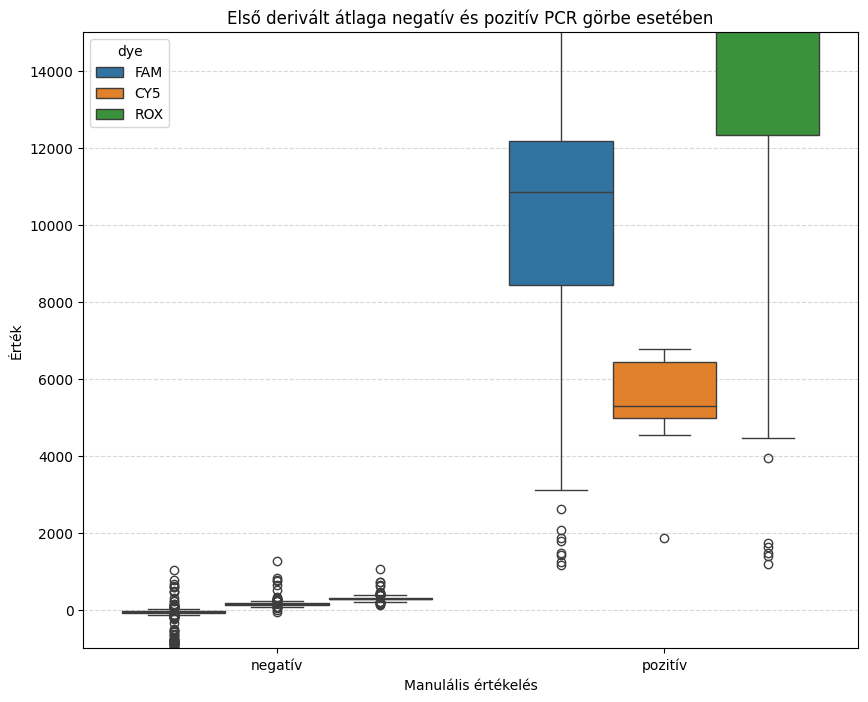

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.boxplot(data=all_manual_result_no_vic, x="manual_result", y="dy_mean", hue='dye')
plt.title("Első derivált átlaga negatív és pozitív PCR görbe esetében")
plt.xlabel("Manulális értékelés")
plt.ylabel("Érték")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(-1000, 15000)
plt.show()

In [20]:
import plotly.express as px

fig = px.box(
    all_manual_result,
    x="manual_result",
    y="dy_mean",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "ROX": "#7DA78C",
        "CY5": "#744577",
        "VIC": "#6594B1"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 15000])
)

fig.update_layout(
    title=dict(
        text="Első derivált átlaga Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=1100,
    y1=1100,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

In [21]:
c = all_manual_result[all_manual_result['manual_result'] == 'negatív']
d = c[c['dye']== 'CY5']
row = d.loc[d["dy_mean"].idxmax()]
row

PCR                 covid_06
well_position            M19
dye                      CY5
dy_mean          1254.354043
manual_result        negatív
Name: 1993, dtype: object

## Validálás02 - második derivált maximuma

In [22]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_max(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:

    y_smooth = savgol_filter(fluorescence, window, poly)
    dy_one = savgol_filter(y_smooth , window, poly, deriv=2)
    dy_max = dy_one.max()
    return dy_max

In [23]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

all_result_max = pd.DataFrame()
for file in files:
    df_max = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", "ROX"]

    for wp in df_max['well_position'].unique():
        wp_df_max = df_max[df_max['well_position'] == wp]
        cycles = wp_df_max['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df_max[ch][9:].values
            sample_result_max = evaluate_sample_max(cycles, fluorescence, window=9)
            row[ch] = sample_result_max
 
        rows.append(row)
 
    result_max = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_max['PCR'] = file.split("\\")[-1].split(".")[0]
    all_result_max = pd.concat([all_result_max, result_max], ignore_index=True)

all_result_max.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,89.916699,1251.587358,15.866982,58.486470,covid_01
1,A11,90.548940,1401.637085,19.373044,86.341204,covid_01
2,A13,98.319100,1306.619816,18.080574,73.174856,covid_01
3,A15,79.259862,1350.994106,10.852889,71.562761,covid_01
4,A17,89.807818,1269.142520,12.122561,74.901726,covid_01


In [24]:
all_result_max_melted = all_result_max.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_max')
all_result_max_melted.head()

,PCR,well_position,dye,dy_max
0,covid_01,A1,FAM,89.916699
1,covid_01,A11,FAM,90.548940
2,covid_01,A13,FAM,98.319100
3,covid_01,A15,FAM,79.259862
4,covid_01,A17,FAM,89.807818


In [25]:
all_manual_max_result = pd.merge(all_result_max_melted, manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
all_manual_max_result.head()

,PCR,well_position,dye,dy_max,manual_result
0,covid_01,A1,FAM,89.916699,negatív
1,covid_01,A11,FAM,90.548940,negatív
2,covid_01,A13,FAM,98.319100,negatív
3,covid_01,A15,FAM,79.259862,negatív
4,covid_01,A17,FAM,89.807818,negatív


In [26]:
all_manual_max_result_no_vic = all_manual_max_result[all_manual_max_result['dye'] != 'VIC']
all_manual_max_result_no_vic.head()

,PCR,well_position,dye,dy_max,manual_result
0,covid_01,A1,FAM,89.916699,negatív
1,covid_01,A11,FAM,90.548940,negatív
2,covid_01,A13,FAM,98.319100,negatív
3,covid_01,A15,FAM,79.259862,negatív
4,covid_01,A17,FAM,89.807818,negatív


In [27]:
import plotly.express as px

fig = px.box(
    all_manual_max_result,
    x="manual_result",
    y="dy_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#6594B1",
        "ROX": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 14000])
)

fig.update_layout(
    title=dict(
        text="Második derivált maximuma Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.show()

## HPV kit

### Első derivált átlag

In [28]:
from app.pcr.data_loader import eds_extract


hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_1.eds"
hpv_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_2.eds"
hpv_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_3.eds"
hpv_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_4.eds"
hpv_5 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_5.eds"
hpv_6 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_6.eds"
hpv_7 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_7.eds"
hpv_df = eds_extract(hpv_2)
hpv_df.to_excel("C:\\Users\\anett\\Downloads\\hpv_teszt_2.xlsx", index=False)
print(hpv_df.head())

dye  well well_position  cycle    CY5     FAM     VIC
0       1            A1      1  33294  365294  262174
1       1            A1      2  32800  362112  259326
2       1            A1      3  31772  356887  254004
3       1            A1      4  30616  347854  247097
4       1            A1      5  29532  336745  239351


In [29]:
import pandas as pd


hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]
#hpv_files = [hpv_3]

all_result_hpv = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv[df_hpv['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    all_result_hpv = pd.concat([all_result_hpv, result_hpv], ignore_index=True)

all_result_hpv.head()
#all_result_hpv.to_excel("C:\\Users\\anett\\Downloads\\hpv_all.xlsx", index=False)

,well_position,FAM,VIC,CY5,PCR
0,A1,-115.592540,9559.730553,333.041545,hpv_teszt_1
1,A11,-191.774842,16.804564,4698.660089,hpv_teszt_1
2,A13,202.579321,11235.075068,520.109517,hpv_teszt_1
3,A15,15.528237,-26.968991,4551.419058,hpv_teszt_1
4,A17,-781.406693,8979.387175,159.595352,hpv_teszt_1


In [30]:
e7 = all_result_hpv[all_result_hpv['well_position'] == 'I21']
e7

,well_position,FAM,VIC,CY5,PCR
54,I21,130.251118,9546.292766,467.000814,hpv_teszt_1
150,I21,105.964825,4766.914167,2187.051157,hpv_teszt_2
246,I21,87.516293,9871.589006,904.824463,hpv_teszt_3
342,I21,108.506242,4827.087305,2650.600361,hpv_teszt_4
438,I21,59.251250,6687.775453,3093.522303,hpv_teszt_5
534,I21,13685.403342,26.185755,59.708947,hpv_teszt_6
630,I21,12912.227407,26.815416,55.411155,hpv_teszt_7


In [31]:
all_result_hpv_melted = all_result_hpv.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')
all_result_hpv_melted.head()

,PCR,well_position,dye,dy_mean
0,hpv_teszt_1,A1,FAM,-115.592540
1,hpv_teszt_1,A11,FAM,-191.774842
2,hpv_teszt_1,A13,FAM,202.579321
3,hpv_teszt_1,A15,FAM,15.528237
4,hpv_teszt_1,A17,FAM,-781.406693


In [32]:
hpv_manual_result = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260425_manulis_ertekeles_hpv.xlsx")
hpv_manual_result_curves = hpv_manual_result.drop(columns=["minta", "target"], axis=1)
hpv_manual_result_curves_melted = hpv_manual_result_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
hpv_manual_result_curves_melted.head()


,well_position,PCR,dye,manual_result
0,A1,hpv_teszt_1,FAM,negatív
1,A11,hpv_teszt_1,FAM,negatív
2,A13,hpv_teszt_1,FAM,negatív
3,A15,hpv_teszt_1,FAM,negatív
4,A17,hpv_teszt_1,FAM,negatív


In [33]:
hpv_all_manual_result = pd.merge(all_result_hpv_melted, hpv_manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
hpv_all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result
0,hpv_teszt_1,A1,FAM,-115.592540,negatív
1,hpv_teszt_1,A11,FAM,-191.774842,negatív
2,hpv_teszt_1,A13,FAM,202.579321,negatív
3,hpv_teszt_1,A15,FAM,15.528237,negatív
4,hpv_teszt_1,A17,FAM,-781.406693,negatív


In [34]:
import plotly.express as px

fig = px.box(
    hpv_all_manual_result,
    x="manual_result",
    y="dy_mean",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    title=dict(text="Első derivált átlaga Légúti panel kitben csatornák szerint", x=0.5),
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 15000])
)

fig.update_layout(
    title=dict(
        text="Első derivált átlaga HPV kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=1100,
    y1=1100,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

In [35]:
import pandas as pd

hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]

all_result_max_hpv = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv_max = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv_max[df_hpv_max['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_max(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv_max = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv_max['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    all_result_max_hpv = pd.concat([all_result_max_hpv, result_hpv_max], ignore_index=True)

all_result_max_hpv.head()


,well_position,FAM,VIC,CY5,PCR
0,A1,355.276817,5673.756311,138.040320,hpv_teszt_1
1,A11,165.993553,27.267030,3630.918723,hpv_teszt_1
2,A13,36.998773,6417.431457,180.292189,hpv_teszt_1
3,A15,156.579342,274.734586,3578.747953,hpv_teszt_1
4,A17,906.269396,5852.181078,232.114316,hpv_teszt_1


In [36]:
all_result_max_hpv_melted = all_result_max_hpv.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_max')
all_result_max_hpv_melted.head()

,PCR,well_position,dye,dy_max
0,hpv_teszt_1,A1,FAM,355.276817
1,hpv_teszt_1,A11,FAM,165.993553
2,hpv_teszt_1,A13,FAM,36.998773
3,hpv_teszt_1,A15,FAM,156.579342
4,hpv_teszt_1,A17,FAM,906.269396


In [37]:
hpv_all_manual_max_result = pd.merge(all_result_max_hpv_melted, hpv_manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
hpv_all_manual_max_result.head()

,PCR,well_position,dye,dy_max,manual_result
0,hpv_teszt_1,A1,FAM,355.276817,negatív
1,hpv_teszt_1,A11,FAM,165.993553,negatív
2,hpv_teszt_1,A13,FAM,36.998773,negatív
3,hpv_teszt_1,A15,FAM,156.579342,negatív
4,hpv_teszt_1,A17,FAM,906.269396,negatív


In [38]:
import plotly.express as px

fig = px.box(
    hpv_all_manual_max_result,
    x="manual_result",
    y="dy_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    title=dict(text="Első derivált átlaga a HPV kitben csatornál szerint", x=0.5),
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 15000])
)

fig.update_layout(
    title=dict(
        text="Második derivált maximuma a HPV kitben csatornák szerint",
        x=0.5
    )
)

#fig.add_hline(
    #y=1000,
    #line_dash="dash",
    #line_color="gray",
    #annotation_text="threshold",
    #annotation_position="top left")

#fig.add_shape(
    #type="line",
    #xref="paper",   # ← EZ A LÉNYEG
    #x0=0,
    #x1=1,
    #yref="y",
    #y0=1000,
    #y1=1000,
    #line=dict(color="gray", width=2, dash="dash"))


fig.show()

In [39]:
k = hpv_all_manual_max_result[hpv_all_manual_max_result['manual_result'] == 'negatív']
k['dy_max'].max()

np.float64(2909.26608852913)

In [40]:
row = k.loc[k["dy_max"].idxmax()]
row

PCR              hpv_teszt_2
well_position            M21
dye                      FAM
dy_max           2909.266089
manual_result        negatív
Name: 174, dtype: object

## Konfúziós mártix - Légúti PCR kit

### PCR görbék

In [41]:
import numpy as np

threshold = 1100
all_manual_result['predikcio'] = np.where(all_manual_result['dy_mean'] > threshold, 'pozitív', 'negatív')
all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result,predikcio
0,covid_01,A1,FAM,-64.914202,negatív,negatív
1,covid_01,A11,FAM,-75.514159,negatív,negatív
2,covid_01,A13,FAM,-50.864883,negatív,negatív
3,covid_01,A15,FAM,-74.851208,negatív,negatív
4,covid_01,A17,FAM,-42.495349,negatív,negatív


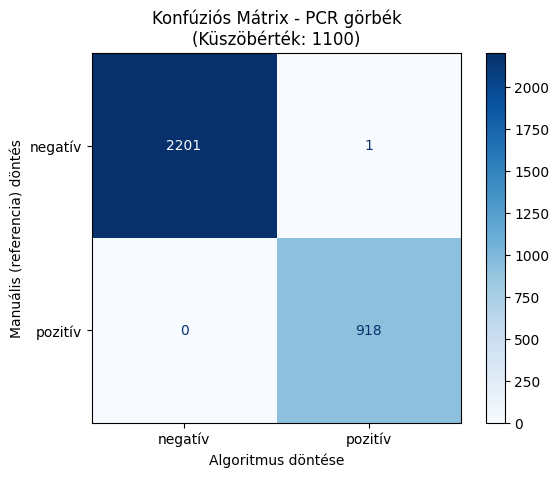

In [42]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív']
cm = confusion_matrix(all_manual_result['manual_result'], all_manual_result['predikcio'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix - PCR görbék\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_leguti.png')
plt.show()

In [43]:
elteresek_curves = all_manual_result[all_manual_result['manual_result'] != all_manual_result['predikcio']]

# Nézzük meg az első pár ilyen esetet
elteresek_curves

,PCR,well_position,dye,dy_mean,manual_result,predikcio
1993,covid_06,M19,CY5,1254.354043,negatív,pozitív


In [45]:
tn, fp, fn, tp = cm.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

Szenzitivitás: 100.00%
Specificitás: 99.95%
Pontosság: 99.97%
PPV (Pozitív prediktív érték): 99.89%
NPV (Negatív prediktív érték): 100.00%


### Minták

In [46]:
leguti_sample_manual = manual_result [['PCR', 'well_position', 'minta', 'target']]
leguti_sample_manual = leguti_sample_manual.query("minta != 'kontroll'")
leguti_sample_manual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 747 entries, 0 to 779
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PCR            747 non-null    object
 1   well_position  747 non-null    object
 2   minta          747 non-null    object
 3   target         124 non-null    object
dtypes: object(4)
memory usage: 29.2+ KB


In [47]:
leguti_file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260426_sample_results_leguti.xlsx"
leguti_sample = pd.read_excel(leguti_file)
kizárandó = ['Valid NTC', 'Valid PK', 'Valid PrepNTC']
leguti_sample = leguti_sample[~leguti_sample['minta'].isin(kizárandó)]
leguti_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 747 entries, 0 to 778
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PCR            747 non-null    object
 1   well           747 non-null    int64 
 2   well_position  747 non-null    object
 3   minta          747 non-null    object
 4   target         124 non-null    object
 5   flag           2 non-null      object
dtypes: int64(1), object(5)
memory usage: 40.9+ KB


In [48]:
leguti_samples_all = pd.merge(leguti_sample, leguti_sample_manual, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
leguti_samples_all.head()

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
0,covid_01,1,A1,negatív,NaN,NaN,negatív,NaN
1,covid_01,3,A3,negatív,NaN,NaN,negatív,NaN
2,covid_01,5,A5,negatív,NaN,NaN,negatív,NaN
3,covid_01,7,A7,negatív,NaN,NaN,negatív,NaN
4,covid_01,9,A9,negatív,NaN,NaN,negatív,NaN


In [49]:
leguti_samples_all[leguti_samples_all['minta_manual'] == 'invalid']

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
99,covid_02,243,K3,invalid,NaN,NaN,invalid,NaN
101,covid_02,291,M3,invalid,NaN,NaN,invalid,NaN


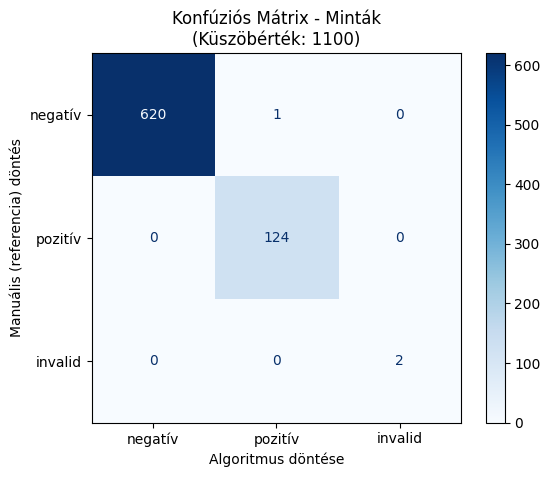

In [50]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív', 'invalid']
cm_sample = confusion_matrix(leguti_samples_all['minta_manual'], leguti_samples_all['minta'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sample, display_labels=labels)
disp.plot(cmap=plt.cm.Blues) 
plt.title(f'Konfúziós Mátrix - Minták\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_leguti_samples.png')
plt.show()

In [51]:
# Csak azokat a sorokat tartjuk meg, ahol a két oszlop nem egyezik
elteresek = leguti_samples_all[leguti_samples_all['minta'] != leguti_samples_all['minta_manual']]

# Nézzük meg az első pár ilyen esetet
elteresek

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
418,covid_06,307,M19,pozitív,Influenza A és B,manuális értékelést igényel,negatív,NaN


In [52]:
tn, fp, fn, tp = cm_sample.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

ValueError: too many values to unpack (expected 4)

## Konfúziós mártix - HPV kit

### PCR görbék

In [53]:
hpv_all_manual_result
import numpy as np

threshold = 1100
hpv_all_manual_result['predikcio'] = np.where(hpv_all_manual_result['dy_mean'] > threshold, 'pozitív', 'negatív')
hpv_all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result,predikcio
0,hpv_teszt_1,A1,FAM,-115.592540,negatív,negatív
1,hpv_teszt_1,A11,FAM,-191.774842,negatív,negatív
2,hpv_teszt_1,A13,FAM,202.579321,negatív,negatív
3,hpv_teszt_1,A15,FAM,15.528237,negatív,negatív
4,hpv_teszt_1,A17,FAM,-781.406693,negatív,negatív


In [54]:
hpv_all_manual_result[hpv_all_manual_result['manual_result'] != hpv_all_manual_result['predikcio'] ]

,PCR,well_position,dye,dy_mean,manual_result,predikcio
1464,hpv_teszt_2,E1,CY5,1002.629864,pozitív,negatív


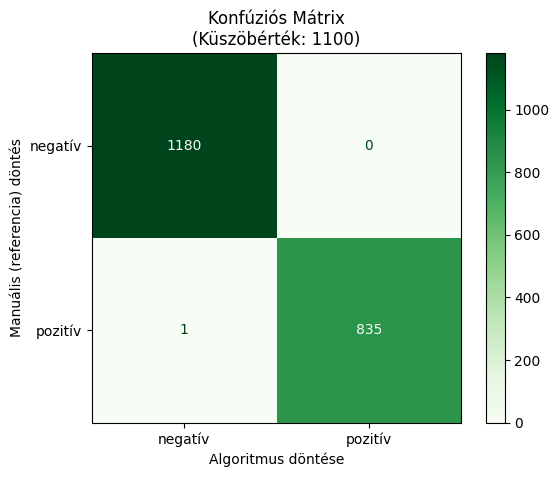

In [55]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív']
hpv_cm = confusion_matrix(hpv_all_manual_result['manual_result'], hpv_all_manual_result['predikcio'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_cm, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv.png')
plt.show()

In [56]:
tn, fp, fn, tp = cm.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

Szenzitivitás: 100.00%
Specificitás: 99.95%
Pontosság: 99.97%
PPV (Pozitív prediktív érték): 99.89%
NPV (Negatív prediktív érték): 100.00%


### Minták

In [57]:
hpv_manual_result
hpv_sample_manual = hpv_manual_result [['PCR', 'well_position', 'minta', 'target']]
hpv_sample_manual = hpv_sample_manual.query("minta != 'kontroll'")
hpv_sample_manual.head()


,PCR,well_position,minta,target
0,hpv_teszt_1,A1,pozitív,HPV 16
1,hpv_teszt_1,A11,negatív,NaN
2,hpv_teszt_1,A13,pozitív,HPV 16
3,hpv_teszt_1,A15,negatív,NaN
4,hpv_teszt_1,A17,pozitív,HPV 16


In [58]:
hpv_file = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260426_sample_results_hpv.xlsx"
hpv_sample = pd.read_excel(hpv_file)
kizárandó = ['Valid NTC', 'Valid PK', 'Valid PrepNTC']
hpv_sample = hpv_sample[~hpv_sample['minta'].isin(kizárandó)]
hpv_sample.head()

,PCR,well,well_position,minta,target,flag
0,hpv_teszt_1,1,A1,pozitív,HPV 16,NaN
1,hpv_teszt_1,3,A3,negatív,NaN,NaN
2,hpv_teszt_1,5,A5,pozitív,HPV 16,NaN
3,hpv_teszt_1,7,A7,negatív,NaN,NaN
4,hpv_teszt_1,9,A9,pozitív,HPV 16,NaN


In [59]:
hpv_samples_all = pd.merge(hpv_sample, hpv_sample_manual, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
hpv_samples_all.head()

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
0,hpv_teszt_1,1,A1,pozitív,HPV 16,NaN,pozitív,HPV 16
1,hpv_teszt_1,3,A3,negatív,NaN,NaN,negatív,NaN
2,hpv_teszt_1,5,A5,pozitív,HPV 16,NaN,pozitív,HPV 16
3,hpv_teszt_1,7,A7,negatív,NaN,NaN,negatív,NaN
4,hpv_teszt_1,9,A9,pozitív,HPV 16,NaN,pozitív,HPV 16


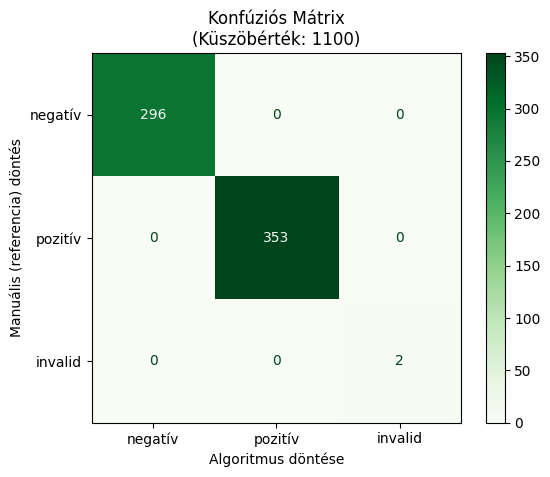

In [60]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív', 'invalid']
hpv_cm_sample = confusion_matrix(hpv_samples_all['minta_manual'], hpv_samples_all['minta'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_cm_sample, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv_samples.png')
plt.show()

In [61]:
tn, fp, fn, tp = hpv_cm_sample.ravel()

# Számítások
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"Szenzitivitás: {sensitivity:.2%}")
print(f"Specificitás: {specificity:.2%}")
print(f"Pontosság: {accuracy:.2%}")
print(f"PPV (Pozitív prediktív érték): {ppv:.2%}")
print(f"NPV (Negatív prediktív érték): {npv:.2%}")

ValueError: too many values to unpack (expected 4)

### Kóczi

In [63]:
hpv_koczi = pd.read_excel(r"C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260504_manulis_ertekeles_hpv_Koczi.xlsx")


#### PCR görbék

In [64]:

hpv_koczi_curves = hpv_koczi.drop(columns=["minta", "target"], axis=1)
hpv_koczi_curves_melted = hpv_koczi_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
hpv_koczi_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,hpv_teszt_1,FAM,negatív
1,A11,hpv_teszt_1,FAM,negatív
2,A13,hpv_teszt_1,FAM,negatív
3,A15,hpv_teszt_1,FAM,negatív
4,A17,hpv_teszt_1,FAM,negatív


In [69]:
hpv_koczi_all_curves = pd.merge(all_result_hpv_melted, hpv_koczi_curves_melted, on=["PCR", "well_position", "dye"], how="left")
threshold = 1000
hpv_koczi_all_curves['predikcio'] = np.where(hpv_koczi_all_curves['dy_mean'] > threshold, 'pozitív', 'negatív')
hpv_koczi_all_curves.head()

,PCR,well_position,dye,dy_mean,manual_result,predikcio
0,hpv_teszt_1,A1,FAM,-115.592540,negatív,negatív
1,hpv_teszt_1,A11,FAM,-191.774842,negatív,negatív
2,hpv_teszt_1,A13,FAM,202.579321,negatív,negatív
3,hpv_teszt_1,A15,FAM,15.528237,negatív,negatív
4,hpv_teszt_1,A17,FAM,-781.406693,negatív,negatív


In [70]:
hpv_koczi_all_curves[hpv_koczi_all_curves['manual_result'] != hpv_koczi_all_curves['predikcio'] ]

,PCR,well_position,dye,dy_mean,manual_result,predikcio
1464,hpv_teszt_2,E1,CY5,1002.629864,negatív,pozitív
1530,hpv_teszt_2,O21,CY5,1253.821060,negatív,pozitív


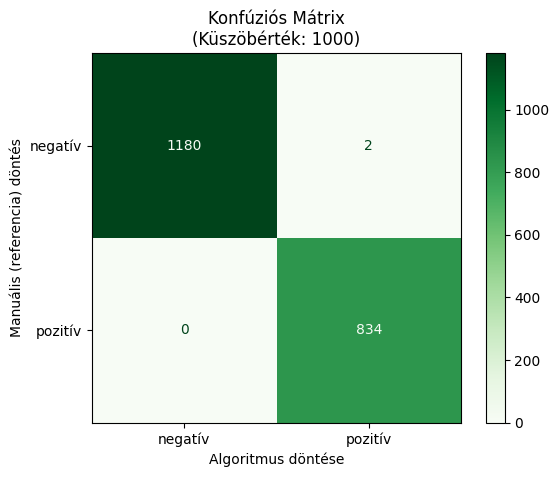

In [71]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív']
hpv_koczi_cm = confusion_matrix(hpv_koczi_all_curves['manual_result'], hpv_koczi_all_curves['predikcio'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_koczi_cm, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv.png')
plt.show()

#### Minták

In [72]:
hpv_koczi_sample = hpv_koczi[['PCR', 'well_position', 'minta', 'target']]
hpv_koczi_sample = hpv_koczi_sample.query("minta != 'kontroll'")
hpv_koczi_sample.head()
hpv_koczi_sample.head()



,PCR,well_position,minta,target
0,hpv_teszt_1,A1,pozitív,HPV 16
1,hpv_teszt_1,A11,negatív,NaN
2,hpv_teszt_1,A13,pozitív,HPV 16
3,hpv_teszt_1,A15,negatív,NaN
4,hpv_teszt_1,A17,pozitív,HPV 16


In [74]:
hpv_koczi_all_samples = pd.merge(hpv_sample, hpv_koczi_sample, on=["PCR", "well_position"], how="left",suffixes=('', '_manual'))
hpv_koczi_all_samples.head()

,PCR,well,well_position,minta,target,flag,minta_manual,target_manual
0,hpv_teszt_1,1,A1,pozitív,HPV 16,NaN,pozitív,HPV 16
1,hpv_teszt_1,3,A3,negatív,NaN,NaN,negatív,NaN
2,hpv_teszt_1,5,A5,pozitív,HPV 16,NaN,pozitív,HPV 16
3,hpv_teszt_1,7,A7,negatív,NaN,NaN,negatív,NaN
4,hpv_teszt_1,9,A9,pozitív,HPV 16,NaN,pozitív,HPV 16


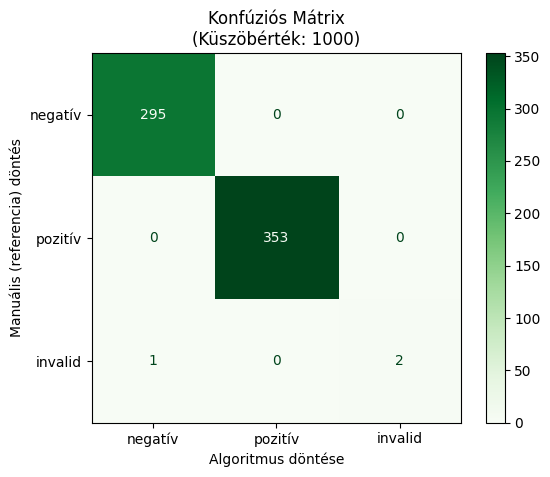

In [75]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negatív', 'pozitív', 'invalid']
hpv_koczi_cm_sample = confusion_matrix(hpv_koczi_all_samples['minta_manual'], hpv_koczi_all_samples['minta'], labels=labels)

# 4. Megjelenítés
disp = ConfusionMatrixDisplay(confusion_matrix=hpv_koczi_cm_sample, display_labels=labels)
disp.plot(cmap=plt.cm.Greens) # Zöld színskála a diagnosztikai siker jelzésére
plt.title(f'Konfúziós Mátrix\n(Küszöbérték: {threshold})')
plt.xlabel('Algoritmus döntése')
plt.ylabel('Manuális (referencia) döntés')
plt.savefig('C:\\Users\\anett\\Downloads\\konfuzios_matrix_hpv_samples.png')
plt.show()